# HydroDiffusion Model Analysis
Evaluate ensemble of trained runs, visualise performance metrics and hydrographs.

In [1]:
import sys, os, json
REPO_ROOT = os.path.abspath('..')
sys.path.insert(0, REPO_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import torch

from analysis.performance_functions import nse, kge, crps_ensemble

RUNS_DIR   = Path(REPO_ROOT) / 'runs'
RAW_DIR    = Path('/projects/standard/kumarv/renga/Public/DATA/camels_us_531/RAW')
SPLIT_CSV  = Path('/projects/standard/kumarv/public/eacvi-fhnn-data/camels_active_learning_splits/camels_split_geo.csv')

LATLONG    = np.load(RAW_DIR / 'latlong.npy',    allow_pickle=True)
BASIN_LIST = np.load(RAW_DIR / 'Basin_List.npy', allow_pickle=True)

ll_df = pd.DataFrame(LATLONG, columns=['lat', 'lon'])
ll_df['gauge_id'] = BASIN_LIST.astype(str)

split_df = pd.read_csv(SPLIT_CSV)
split_df['gauge_id'] = split_df['gauge_id'].astype(str).str.zfill(8)
print(f'Split counts: {split_df.split.value_counts().to_dict()}')
print(f'Runs dir: {RUNS_DIR}')

Split counts: {'sample': 431, 'eval': 53, 'seed': 47}
Runs dir: /projects/standard/kumarv/badit004/HydroDiffusion_ActiveLearning/runs


## Config — find completed runs

In [16]:
# Adjust MODEL_PATTERN to match the runs you want to analyse.
# Only directories that contain best_model.pt (i.e. training completed) are included.
#MODEL_PATTERN = '20260526/al-r1-random_decoder-only-ssm_geo_s1_seed*'
MODEL_PATTERN = '20260526_baseline_encdec-lstm_geo_s1_seed*'

run_dirs = sorted([
    p for p in RUNS_DIR.glob(MODEL_PATTERN)
    if (p / 'best_model.pt').exists()
])

print(f'Found {len(run_dirs)} completed runs:')
for r in run_dirs:
    has_preds = (r / 'predictions.npz').exists()
    print(f'  {r.name}  [{"predictions ready" if has_preds else "needs eval"  }]')

Found 5 completed runs:
  20260526_baseline_encdec-lstm_geo_s1_seed3407  [predictions ready]
  20260526_baseline_encdec-lstm_geo_s1_seed3408  [predictions ready]
  20260526_baseline_encdec-lstm_geo_s1_seed3409  [predictions ready]
  20260526_baseline_encdec-lstm_geo_s1_seed3410  [predictions ready]
  20260526_baseline_encdec-lstm_geo_s1_seed3411  [predictions ready]


## Step 1 — Evaluate each seed (skip if predictions.npz already exists)

In [17]:
from papercode.evaluate_npy import evaluate as _evaluate

DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

def _load_cfg(run_dir: Path) -> dict:
    """Load cfg.json and coerce string values back to correct Python types."""
    with open(run_dir / 'cfg.json') as f:
        raw = json.load(f)

    # cfg.json was saved with str(v) for every value — convert back
    bool_keys  = {'no_static', 'concat_static', 'cache_data', 'clip_norm', 'prenorm', 'resume', 'use_mse'}
    int_keys   = {'hidden_size', 'batch_size', 'forecast_horizon', 'seq_length',
                  'initial_forget_gate_bias', 'time_emb_dim', 'ddim_steps',
                  'stride', 'static_dim', 'lstm_nlayers', 'unet_nfeat', 'n_layers',
                  'd_model', 'd_state', 'clip_value', 'log_interval', 'num_workers',
                  'num_samples'}
    float_keys = {'dropout', 'ssm_dropout', 'lr', 'lr_min', 'lr_dt', 'weight_decay',
                  'wd', 'min_dt', 'max_dt', 'cfr', 'cfi', 'learning_rate', 'eta'}
    date_keys  = {'train_start', 'train_end', 'val_start', 'val_end', 'test_start', 'test_end'}

    cfg = {}
    for k, v in raw.items():
        if v == 'None':
            cfg[k] = None
        elif k in bool_keys:
            cfg[k] = v.lower() == 'true'
        elif k in int_keys:
            try: cfg[k] = int(v)
            except (ValueError, TypeError): cfg[k] = v
        elif k in float_keys:
            try: cfg[k] = float(v)
            except (ValueError, TypeError): cfg[k] = v
        elif k in date_keys:
            cfg[k] = pd.to_datetime(v)
        else:
            cfg[k] = v

    # Override / add runtime settings
    cfg['run_dir']     = str(run_dir)
    cfg['DEVICE']      = DEVICE
    cfg['num_workers'] = 2
    cfg['stride']      = 90
    return cfg


for run_dir in run_dirs:
    pred_path = run_dir / 'predictions.npz'
    if pred_path.exists():
        print(f'[SKIP]  {run_dir.name}')
        continue
    print(f'[EVAL]  {run_dir.name} ...')
    cfg = _load_cfg(run_dir)
    _evaluate(cfg)
    print(f'  → saved {pred_path}')

print('Done.')

Device: cuda:0
[SKIP]  20260526_baseline_encdec-lstm_geo_s1_seed3407
[SKIP]  20260526_baseline_encdec-lstm_geo_s1_seed3408
[SKIP]  20260526_baseline_encdec-lstm_geo_s1_seed3409
[SKIP]  20260526_baseline_encdec-lstm_geo_s1_seed3410
[SKIP]  20260526_baseline_encdec-lstm_geo_s1_seed3411
Done.


## Step 2 — Load predictions and aggregate across seeds

In [18]:
preds_list, ens_list = [], []
ref = None
for run_dir in run_dirs:
    d = np.load(run_dir / 'predictions.npz', allow_pickle=True)
    if ref is None:
        ref = d
    preds_list.append(d['preds'].astype(np.float32))
    if 'ens' in d.files:
        ens_list.append(d['ens'].astype(np.float32))   # (N, S, H)

ens_preds  = np.stack(preds_list, axis=0)   # (n_seeds, N, H)
mean_preds = ens_preds.mean(axis=0)         # (N, H)
seed_var   = ens_preds.var(axis=0)          # (N, H) — inter-seed variance

obs    = ref['obs'].astype(np.float32)      # (N, H)
basins = ref['basins'].astype(str)          # (N,)
dates  = pd.to_datetime(ref['dates'])       # (N,)
H      = mean_preds.shape[1]

# Merge all seed × sample trajectories into one big ensemble for CRPS:
# (n_seeds, N, S, H) → (N, n_seeds*S, H)
has_ens = len(ens_list) == len(run_dirs)
if has_ens:
    all_ens_np = np.stack(ens_list, axis=0)              # (n_seeds, N, S, H)
    n_seeds_e, N_e, S_e, H_e = all_ens_np.shape
    S_total = n_seeds_e * S_e
    merged_ens = all_ens_np.transpose(1, 0, 2, 3).reshape(N_e, S_total, H_e)
    print(f'Merged ensemble shape: {merged_ens.shape}  (N, S_total, H)')

print(f'N={len(basins):,}  H={H}  seeds={len(preds_list)}')
print(f'Unique basins: {len(np.unique(basins))}')

N=327,800  H=8  seeds=5
Unique basins: 100


## Step 3 — Per-basin metrics

In [19]:
unique_basins = np.unique(basins)
basin_metrics = []
for gid in unique_basins:
    mask = basins == gid
    df_bp = pd.DataFrame({'qobs': obs[mask].ravel(), 'qsim': mean_preds[mask].ravel()})
    kge_val, *_ = kge(df_bp)
    row = {'gauge_id': gid, 'nse': nse(df_bp), 'kge': kge_val}
    if has_ens:
        o_flat = obs[mask].ravel()                          # (T*H,)
        e_flat = merged_ens[mask].reshape(-1, S_total)      # (T*H, S_total)
        row['crps'] = crps_ensemble(o_flat, e_flat)
    basin_metrics.append(row)

metrics_df = (pd.DataFrame(basin_metrics)
              .merge(split_df[['gauge_id','split']], on='gauge_id', how='left')
              .merge(ll_df, on='gauge_id', how='left'))

metric_cols = ['nse', 'kge'] + (['crps'] if has_ens else [])
print(len(metrics_df))
print(metrics_df["split"].value_counts())
print('Overall:')
print(metrics_df[metric_cols].describe().round(3))
print('\nMedian by split:')
print(metrics_df.groupby('split')[metric_cols].median().round(3))

100
split
eval    53
seed    47
Name: count, dtype: int64
Overall:
           nse      kge
count  100.000  100.000
mean     0.543    0.592
std      0.460    0.296
min     -3.162   -0.315
25%      0.489    0.514
50%      0.690    0.704
75%      0.750    0.792
max      0.889    0.895

Median by split:
         nse    kge
split              
eval   0.598  0.587
seed   0.735  0.769


## Step 4 — Loss curves

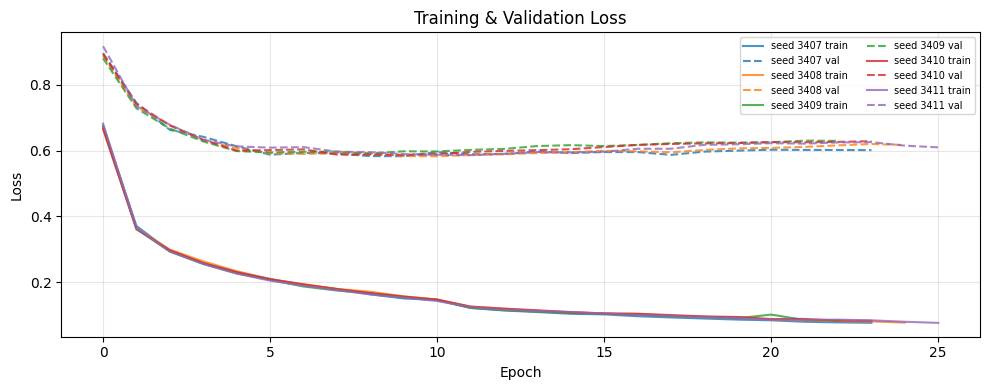

In [20]:
fig, ax = plt.subplots(figsize=(10, 4))
colors = plt.cm.tab10.colors
for i, run_dir in enumerate(run_dirs):
    loss_path = run_dir / 'loss_history.json'
    if not loss_path.exists(): continue
    with open(loss_path) as f:
        hist = json.load(f)
    seed = run_dir.name.split('seed')[-1]
    ax.plot(hist['train_loss'], color=colors[i], ls='-',  label=f'seed {seed} train', alpha=0.8)
    ax.plot(hist['val_loss'],   color=colors[i], ls='--', label=f'seed {seed} val',   alpha=0.8)
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss'); ax.set_title('Training & Validation Loss')
ax.legend(fontsize=7, ncol=2); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Step 5 — NSE / KGE boxplots by split

/tmp/ipykernel_3672427/416881037.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True,
/tmp/ipykernel_3672427/416881037.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True,


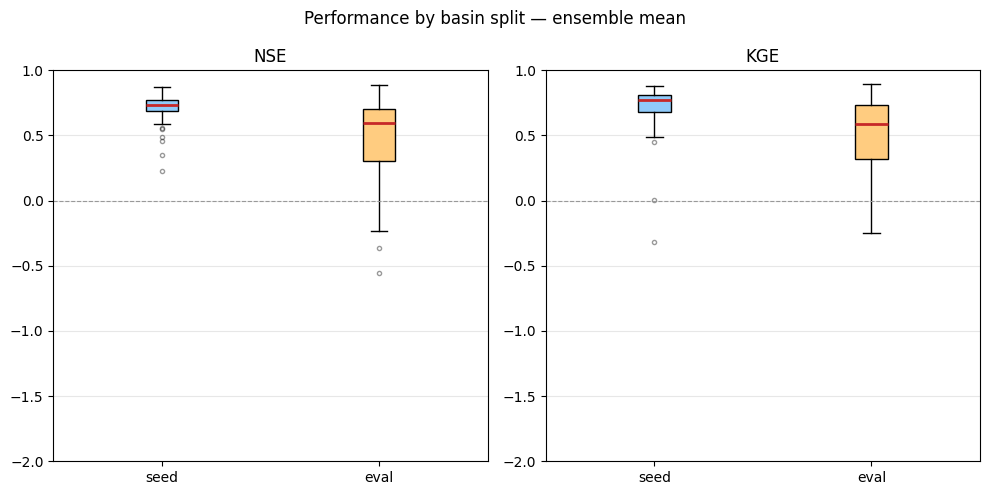

In [21]:
palette = {'seed': '#90CAF9', 'eval': '#FFCC80', 'sample': '#A5D6A7'}
metrics_to_plot = ['nse', 'kge'] + (['crps'] if has_ens else [])
fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(5 * len(metrics_to_plot), 5))
if len(metrics_to_plot) == 1:
    axes = [axes]
for ax, metric in zip(axes, metrics_to_plot):
    data, labels, colors = [], [], []
    for sp in ['seed', 'eval', 'sample']:
        vals = metrics_df.loc[metrics_df['split'] == sp, metric].dropna().values
        if len(vals): data.append(vals); labels.append(sp); colors.append(palette[sp])
    bp = ax.boxplot(data, labels=labels, patch_artist=True,
                    medianprops=dict(color='#C62828', linewidth=2),
                    flierprops=dict(marker='o', markersize=3, alpha=0.4))
    for patch, c in zip(bp['boxes'], colors): patch.set_facecolor(c)
    ax.set_title(metric.upper())
    if metric == 'crps':
        ax.set_ylim(bottom=0)
    else:
        ax.set_ylim(-2, 1)
        ax.axhline(0, color='#999', ls='--', lw=0.8)
    ax.grid(axis='y', alpha=0.3)
fig.suptitle('Performance by basin split — ensemble mean')
plt.tight_layout(); plt.show()

## Step 6 — NSE by forecast lead day

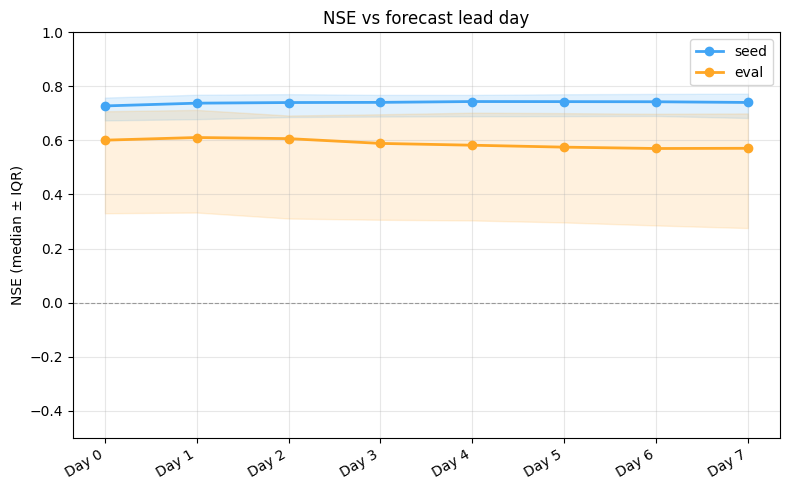

In [22]:
lead_nse = {sp: [] for sp in ['seed', 'eval', 'sample']}
for gid in unique_basins:
    mask = basins == gid
    sp_arr = metrics_df.loc[metrics_df['gauge_id'] == gid, 'split'].values
    if len(sp_arr) == 0 or sp_arr[0] not in lead_nse: continue
    sp = sp_arr[0]
    lead_nse[sp].append([nse(pd.DataFrame({'qobs': obs[mask, t], 'qsim': mean_preds[mask, t]})) for t in range(H)])

fig, ax = plt.subplots(figsize=(8, 5))
pal = {'seed': '#42A5F5', 'eval': '#FFA726', 'sample': '#66BB6A'}
days = np.arange(H)
for sp, color in pal.items():
    arr = np.array(lead_nse[sp])
    if arr.size == 0: continue
    med = np.nanmedian(arr, axis=0)
    ax.plot(days, med, color=color, marker='o', lw=2, label=sp)
    ax.fill_between(days, np.nanpercentile(arr, 25, axis=0), np.nanpercentile(arr, 75, axis=0), color=color, alpha=0.15)
ax.set_xticks(days); ax.set_xticklabels([f'Day {d}' for d in days], rotation=30, ha='right')
ax.set_ylabel('NSE (median ± IQR)'); ax.set_ylim(-0.5, 1.0)
ax.axhline(0, color='#999', ls='--', lw=0.8); ax.set_title('NSE vs forecast lead day')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

## Step 7 — Spatial map of NSE

47
53


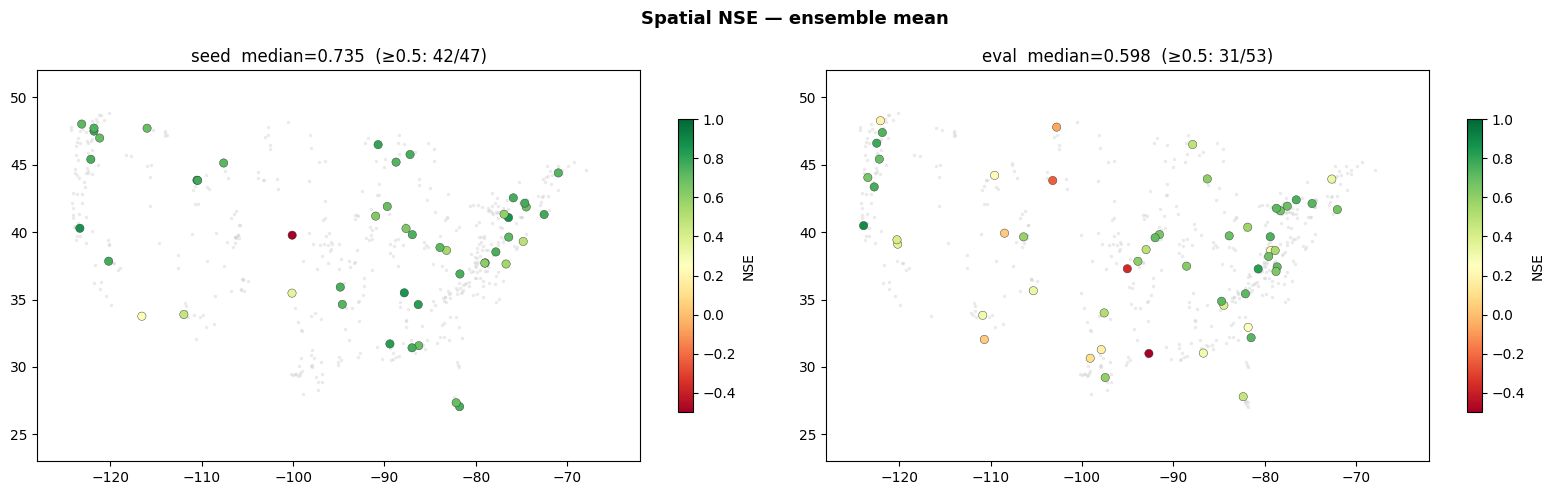

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, sp in zip(axes, ['seed', 'eval']):
    sub = metrics_df[metrics_df['split'] == sp].dropna(subset=['lat', 'lon', 'nse'])
    print(len(sub))
    ax.scatter(ll_df['lon'], ll_df['lat'], s=6, c='#CCCCCC', alpha=0.4, linewidths=0)
    sc = ax.scatter(sub['lon'], sub['lat'], c=sub['nse'],
                    cmap='RdYlGn', vmin=-0.5, vmax=1.0, edgecolors='#333', linewidths=0.3)
    plt.colorbar(sc, ax=ax, shrink=0.75, label='NSE')
    ax.set_title(f'{sp}  median={sub["nse"].median():.3f}  (≥0.5: {(sub["nse"]>=0.5).sum()}/{len(sub)})')
    ax.set_xlim(-128, -62); ax.set_ylim(23, 52)
fig.suptitle('Spatial NSE — ensemble mean', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## Step 8 — Hydrographs: best and worst basins per split


── seed ──


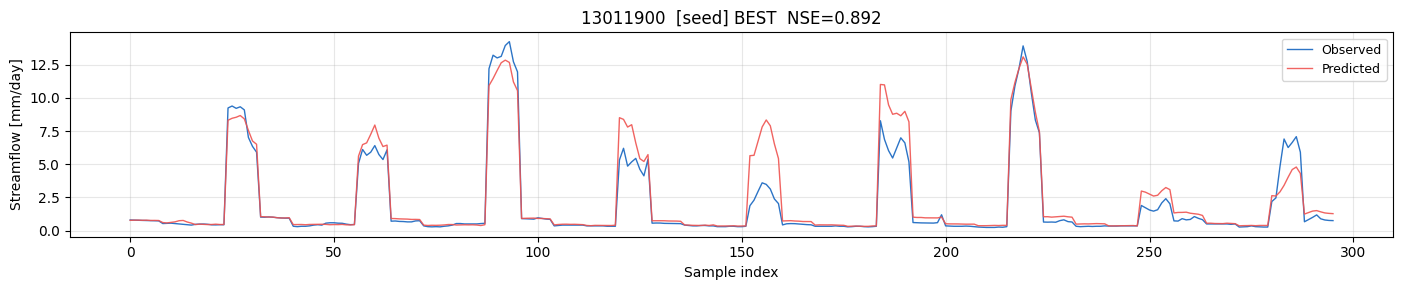

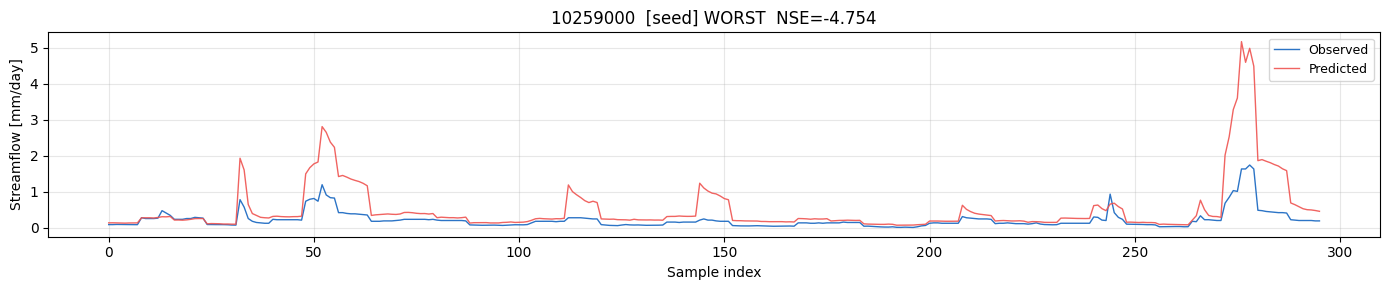


── eval ──


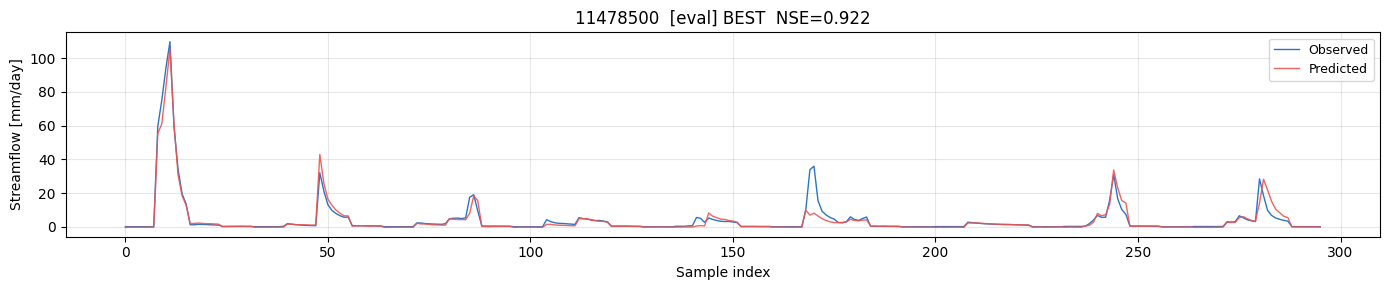

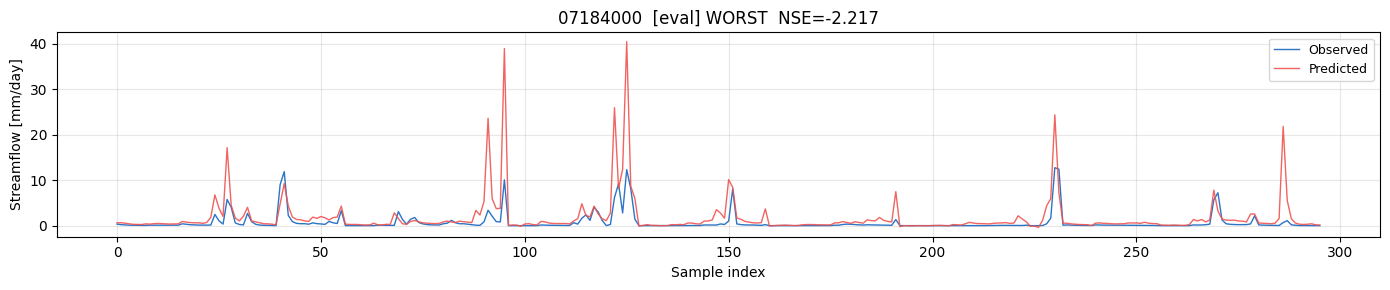

In [10]:
def plot_hydrograph(gauge_id, label=''):
    mask = basins == gauge_id
    if not mask.any(): return
    o = obs[mask].ravel()
    p = mean_preds[mask].ravel()
    nse_val = nse(pd.DataFrame({'qobs': o, 'qsim': p}))
    fig, ax = plt.subplots(figsize=(14, 3))
    ax.plot(o, color='#1565C0', lw=1, alpha=0.9, label='Observed')
    ax.plot(p, color='#EF5350', lw=1, alpha=0.9, label='Predicted')
    ax.set_title(f'{gauge_id}  {label}  NSE={nse_val:.3f}')
    ax.set_xlabel('Sample index'); ax.set_ylabel('Streamflow [mm/day]')
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

for sp in ['seed', 'eval']:
    sub = metrics_df[metrics_df['split'] == sp].dropna(subset=['nse'])
    if sub.empty: continue
    print(f'\n── {sp} ──')
    plot_hydrograph(sub.nlargest(1, 'nse')['gauge_id'].iloc[0],  f'[{sp}] BEST')
    plot_hydrograph(sub.nsmallest(1, 'nse')['gauge_id'].iloc[0], f'[{sp}] WORST')

## Step 9 — Seed ensemble variance (UQ signal for active learning)

Top-10 most uncertain pool basins:
gauge_id  seed_var      lat        lon
06746095  0.464021 40.53998 -105.88279
01435000  0.206681 41.89009  -74.58988
01134500  0.202425 44.51172  -71.83731
06911900  0.130966 38.71069  -95.83603
03078000  0.062536 39.70219  -79.13639
01638480  0.050045 39.25455  -77.57638
02018000  0.026968 37.66596  -79.91144
13018300  0.021429 43.45215 -110.70409
02074500  0.013313 36.61958  -79.50419
08377900  0.007957 35.77725 -105.65807


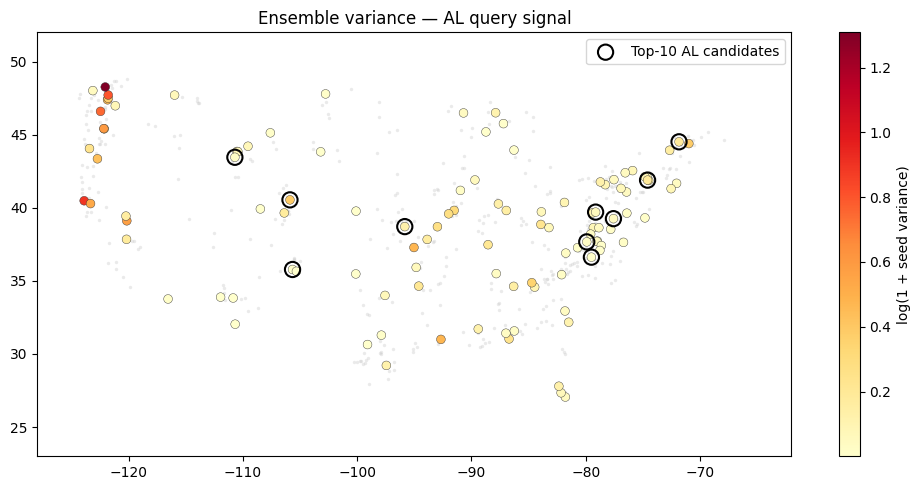

In [11]:
var_df = pd.DataFrame({
    'gauge_id': [gid for gid in unique_basins],
    'seed_var': [float(seed_var[basins == gid].mean()) for gid in unique_basins],
})
var_df = (var_df.merge(split_df[['gauge_id','split']], on='gauge_id', how='left')
                .merge(ll_df, on='gauge_id', how='left'))

pool_candidates = var_df[var_df['split'] == 'sample'].nlargest(10, 'seed_var')
print('Top-10 most uncertain pool basins:')
print(pool_candidates[['gauge_id','seed_var','lat','lon']].to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(ll_df['lon'], ll_df['lat'], s=6, c='#CCCCCC', alpha=0.4, linewidths=0)
sc = ax.scatter(var_df['lon'], var_df['lat'], c=np.log1p(var_df['seed_var']),
                cmap='YlOrRd', s=40, edgecolors='#333', linewidths=0.3)
plt.colorbar(sc, ax=ax, label='log(1 + seed variance)')
ax.scatter(pool_candidates['lon'], pool_candidates['lat'],
           s=120, facecolors='none', edgecolors='black', lw=1.5, zorder=5, label='Top-10 AL candidates')
ax.set_title('Ensemble variance — AL query signal')
ax.set_xlim(-128, -62); ax.set_ylim(23, 52)
ax.legend(); plt.tight_layout(); plt.show()

## Step 10 — NSE progression over AL rounds

[round_comparison] Round 0: averaged 5 seed(s), 100 basins.
[round_comparison] Round 1: averaged 5 seed(s), 110 basins.
[round_comparison] Round 2: no predictions found, skipping.
[round_comparison] Round 3: no predictions found, skipping.
[round_comparison] Round 4: no predictions found, skipping.
Median NSE by round and split:
split   eval  sample   seed
round                      
0      0.452     NaN  0.656
1      0.442   0.727  0.657


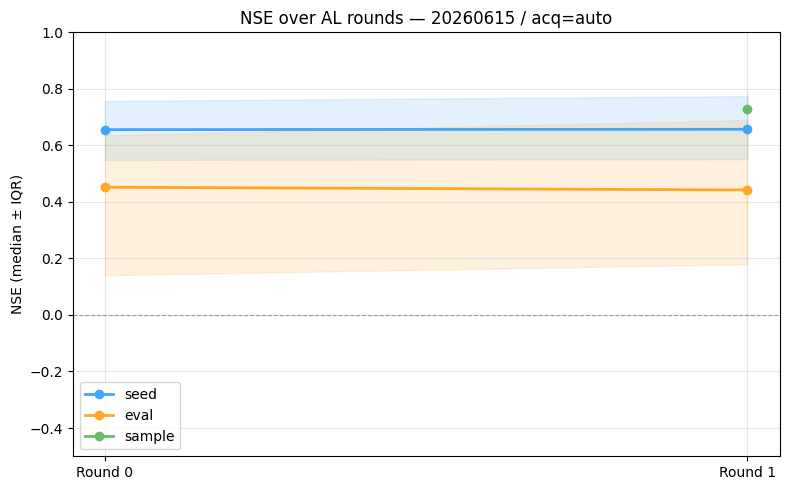

In [14]:
from analysis.round_comparison import collect_round_metrics

# ── Config: set run_date to the date folder for your experiment ─────────
ROUND_DATE  = '20260615'            # e.g. '20260610', '20260615', '20260526'
ROUND_SEEDS = [3407, 3408, 3409, 3410, 3411]
ROUNDS      = [0, 1, 2, 3, 4]      # rounds to compare; missing predictions are skipped
ROUND_ACQ   = None                  # set to e.g. 'epig' or 'random' only if multiple
                                    # experiments share the same date folder
# ────────────────────────────────────────────────────────────────────────

round_metrics_df = collect_round_metrics(
    runs_dir  = RUNS_DIR,
    run_date  = ROUND_DATE,
    seeds     = ROUND_SEEDS,
    rounds    = ROUNDS,
    split_df  = split_df,
    ll_df     = ll_df,
    acq_fn    = ROUND_ACQ,
)

# Summary table
summary = (round_metrics_df
           .groupby(['round', 'split'])['nse']
           .median()
           .unstack('split')
           .round(3))
print('Median NSE by round and split:')
print(summary)

# Plot
pal = {'seed': '#42A5F5', 'eval': '#FFA726', 'sample': '#66BB6A'}
fig, ax = plt.subplots(figsize=(8, 5))
for sp, color in pal.items():
    sub = round_metrics_df[round_metrics_df['split'] == sp]
    if sub.empty:
        continue
    grp = sub.groupby('round')['nse']
    rounds_avail = sorted(grp.groups.keys())
    med = [grp.get_group(r).median() for r in rounds_avail]
    q25 = [grp.get_group(r).quantile(0.25) for r in rounds_avail]
    q75 = [grp.get_group(r).quantile(0.75) for r in rounds_avail]
    ax.plot(rounds_avail, med, color=color, marker='o', lw=2, label=sp)
    ax.fill_between(rounds_avail, q25, q75, color=color, alpha=0.15)
rounds_present = sorted(round_metrics_df['round'].unique())
ax.set_xticks(rounds_present)
ax.set_xticklabels([f'Round {r}' for r in rounds_present])
ax.set_ylabel('NSE (median ± IQR)')
ax.set_ylim(-0.5, 1.0)
ax.axhline(0, color='#999', ls='--', lw=0.8)
acq_label = ROUND_ACQ or 'auto'
ax.set_title(f'NSE over AL rounds — {ROUND_DATE} / acq={acq_label}')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Step 11 — Sites added per AL round (spatial map)

Basins promoted per round:
             n_basins
round_added          
Round 0            47
Round 1            10
Round 2            10


/tmp/ipykernel_3672427/558214209.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', len(rounds_present))


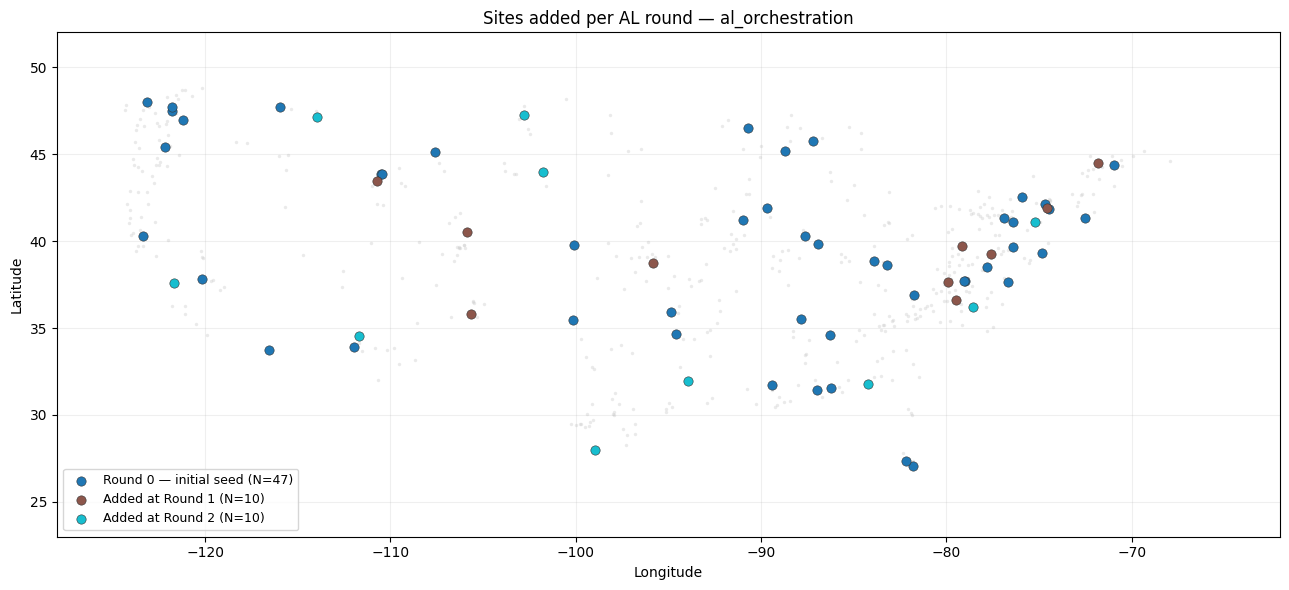

In [15]:
from analysis.round_comparison import get_newly_added_sites

# ── Config ──────────────────────────────────────────────────────────────
ORCH_DIR  = RUNS_DIR / 'al_orchestration'   # or 'al_orchestration_epig'
MAX_ROUND = 2
# ────────────────────────────────────────────────────────────────────────

added_df = get_newly_added_sites(ORCH_DIR, MAX_ROUND)
added_df = added_df.merge(ll_df, on='gauge_id', how='left')

print('Basins promoted per round:')
print(added_df['round_added'].value_counts().sort_index()
      .rename(index=lambda r: f'Round {r}').to_frame('n_basins'))

rounds_present = sorted(added_df['round_added'].unique())
cmap = plt.cm.get_cmap('tab10', len(rounds_present))
round_color = {r: cmap(i) for i, r in enumerate(rounds_present)}

fig, ax = plt.subplots(figsize=(13, 6))
# All basins in grey
ax.scatter(ll_df['lon'], ll_df['lat'], s=6, c='#CCCCCC', alpha=0.4, linewidths=0, zorder=1)

for r in rounds_present:
    sub = added_df[added_df['round_added'] == r].dropna(subset=['lat', 'lon'])
    label = (
        f'Round {r} — initial seed (N={len(sub)})'
        if r == 0 else
        f'Added at Round {r} (N={len(sub)})'
    )
    ax.scatter(
        sub['lon'], sub['lat'],
        s=45, color=round_color[r],
        edgecolors='#333', linewidths=0.4,
        label=label, zorder=2 + r,
    )

ax.set_xlim(-128, -62)
ax.set_ylim(23, 52)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(f'Sites added per AL round — {ORCH_DIR.name}')
ax.legend(loc='lower left', fontsize=9)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()